# AlphaSearchBench Results Explorer

임의의 `evaluate` 실행 결과(out 디렉토리)를 **표와 그래프**로 관찰하는 노트북.

- **사용법**: 아래 `RESULT_DIRS`에 관찰할 run들의 out 경로를 지정하고 전체 실행.
  하나만 넣으면 단일 run 분석, 여러 개면 run 간 비교까지 수행한다.
- 입력 형식: `python -m alphasearchbench evaluate ... --out <dir>` 가 만든
  디렉토리 (`metrics/*.parquet`, `daily/`, `manifests/`).
- 섹션: ①Manifest ②Validity ③OOS ④QD ⑤Backtest ⑥Cross-run 요약


In [72]:
# ---------------- 설정: 관찰할 run 경로 ----------------
from pathlib import Path

# AlphaSearchBench 루트 자동 탐색 (notebooks/에서 실행 기준)
ASB_ROOT = Path.cwd().resolve()
while ASB_ROOT.name != "AlphaSearchBench" and ASB_ROOT != ASB_ROOT.parent:
    ASB_ROOT = ASB_ROOT.parent
assert ASB_ROOT.name == "AlphaSearchBench", "AlphaSearchBench 루트를 찾지 못했습니다 — RESULT_DIRS를 절대경로로 지정하세요"

# ▼▼ 여기만 수정 — {표시이름: out 디렉토리} ▼▼
RESULT_DIRS = {
    "gp_csi800":  ASB_ROOT / "out/pilot/gp_csi800",
    "gp_csi800_signfix":  ASB_ROOT / "out/pilot_signfix/gp_csi800",
}
# 시계열(일별) 그래프를 그릴 대표 run
SELECTED_RUN = "gp_csi800_signfix"


In [73]:
# ---------------- 공통: 로더 · 팔레트 · 스타일 ----------------
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from glob import glob

pd.set_option("display.max_colwidth", 60)

# 한글 폰트: 시스템 Noto Sans CJK가 있으면 등록 (없으면 DejaVu fallback)
for _fp in (sorted(glob("/usr/share/fonts/google-noto-cjk/NotoSansCJK-Regular.ttc"))
            or sorted(glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True))):
    try:
        fm.fontManager.addfont(_fp)
        break
    except Exception:
        pass
_CJK = next((f.name for f in fm.fontManager.ttflist if "Noto Sans CJK" in f.name), None)

# 검증된 기본 팔레트(dataviz reference, light) — run에 고정 순서로 배정(순환 금지)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e87ba4", "#008300"]
MARKERS = ["o", "s", "^", "D", "v", "P"]            # 산점도 보조 인코딩
STATUS_BAD = "#e34948"                                # invalid 전용(상태색 — 계열 재사용 금지)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4df"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#dbe9f9", "#2a78d6", "#123c6b"])
DIV = LinearSegmentedColormap.from_list("div_rb", ["#e34948", "#b8b7b0", "#2a78d6"])

mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False, "axes.unicode_minus": False,
    "font.family": ([_CJK] if _CJK else []) + ["DejaVu Sans"],
})
RUN_COLOR = {name: CAT[i % len(CAT)] for i, name in enumerate(RESULT_DIRS)}
RUN_MARKER = {name: MARKERS[i % len(MARKERS)] for i, name in enumerate(RESULT_DIRS)}

def load_table(run_dir, name, sub="metrics"):
    """parquet 우선, pkl 폴백. 없으면 빈 DataFrame."""
    base = Path(run_dir) / sub / name
    for ext in (".parquet", ".pkl"):
        p = base.with_suffix(ext)
        if p.exists():
            return pd.read_parquet(p) if ext == ".parquet" else pd.read_pickle(p)
    return pd.DataFrame()

def short(f, n=42):
    f = str(f)
    return f if len(f) <= n else f[: n - 1] + "…"

def pshort(f, n=42):
    """plot 텍스트용: $가 mathtext로 해석되지 않게 이스케이프."""
    return short(f, n).replace("$", r"\$")

def spread_ys(ys, min_gap):
    """직접 라벨(y좌표)의 겹침 방지 — 위에서 아래로 최소 간격 확보."""
    ys = np.asarray(ys, dtype=float)
    out = ys.copy()
    order = np.argsort(ys)[::-1]
    for a, b in zip(order[:-1], order[1:]):
        if out[a] - out[b] < min_gap:
            out[b] = out[a] - min_gap
    return out

RUNS = {}
for name, d in RESULT_DIRS.items():
    r = {k: load_table(d, k) for k in
         ["validity_factor_metrics", "oos_factor_metrics", "oos_pool_metrics",
          "qd_factor_descriptors", "qd_pool_metrics",
          "backtest_factor_metrics", "backtest_pool_metrics"]}
    r["oos_daily"] = load_table(d, "oos_daily", "daily")
    r["bt_daily"] = load_table(d, "backtest_daily", "daily")
    mans = sorted(Path(d, "manifests").glob("run_*.json"))
    r["manifest"] = json.loads(mans[-1].read_text()) if mans else {}
    RUNS[name] = r
print("loaded runs:", ", ".join(RUNS))


loaded runs: gp_csi800, gp_csi800_signfix


## 1. Manifest — 실험 정의 확인

In [74]:
rows = []
for name, r in RUNS.items():
    m = r["manifest"]
    rows.append({
        "run": name,
        "market": m.get("market"),
        "benchmark": m.get("benchmark"),
        "train": " ~ ".join(m.get("splits", {}).get("train", ["?", "?"])),
        "test": " ~ ".join(m.get("splits", {}).get("test", ["?", "?"])),
        "execution": m.get("execution", {}).get("execution"),
        "cost(bp)": (m.get("execution", {}).get("transaction_cost_rate") or 0) * 1e4,
        "n_formula": m.get("run", {}).get("formula_count"),
        "n_unique": m.get("run", {}).get("unique_formula_count"),
        "weights": m.get("run", {}).get("weights_source"),
    })
pd.DataFrame(rows).set_index("run")


,market,benchmark,train,test,execution,cost(bp),n_formula,n_unique,weights
run,,,,,,,,,
gp_csi800,csi800,SH000906,2010-01-01 ~ 2016-12-31,2021-01-01 ~ 2024-12-31,next_open_oo,15.0,10,3,equal_default
gp_csi800_signfix,csi800,SH000906,2010-01-01 ~ 2019-12-31,2021-01-01 ~ 2024-12-31,next_open_oo,15.0,10,3,equal_default


## 2. Validity Gate

**coverage가 이봉 분포인지**가 첫 관찰 포인트 — 아티팩트 factor는 coverage가
수 % 미만에 몰린다. 붉은 막대 = hard invalid (downstream 평가 제외).

In [75]:
vt = []
for name, r in RUNS.items():
    v = r["validity_factor_metrics"].copy()
    v.insert(0, "run", name)
    vt.append(v)
VAL = pd.concat(vt, ignore_index=True)
cols = ["run", "formula", "valid", "invalid_reason", "mean_daily_coverage_ratio",
        "median_daily_n_valid", "valid_day_ratio", "const_day_ratio",
        "nan_cell_ratio", "inf_cell_ratio"]
show = VAL[cols].copy()
show["formula"] = show["formula"].map(short)
show.style.format({"mean_daily_coverage_ratio": "{:.4f}", "valid_day_ratio": "{:.2f}",
                   "const_day_ratio": "{:.2f}", "nan_cell_ratio": "{:.3f}",
                   "inf_cell_ratio": "{:.4f}", "median_daily_n_valid": "{:.0f}"}) \
    .background_gradient(subset=["mean_daily_coverage_ratio"], cmap=SEQ, vmin=0, vmax=1)


,run,formula,valid,invalid_reason,mean_daily_coverage_ratio,median_daily_n_valid,valid_day_ratio,const_day_ratio,nan_cell_ratio,inf_cell_ratio
0,gp_csi800,"Rsquare(Std(Var($factor, 6), 30), 5)",True,None,0.0082,2,0.68,0.00,0.992,0.0000
1,gp_csi800,"Div(Less(Power($high, $change), Less(Rsqu…",True,None,0.0082,2,0.68,0.00,0.992,0.0000
2,gp_csi800,"Div(Less(Rsquare(Std(Var($factor, 6), 30)…",True,None,0.0082,2,0.68,0.00,0.992,0.0000
3,gp_csi800_signfix,"Rsquare(Std(Var($factor, 6), 30), 5)",True,None,0.0082,2,0.68,0.00,0.992,0.0000
4,gp_csi800_signfix,"Div(Less(Power($high, $change), Less(Rsqu…",True,None,0.0082,2,0.68,0.00,0.992,0.0000
5,gp_csi800_signfix,"Div(Less(Rsquare(Std(Var($factor, 6), 30)…",True,None,0.0082,2,0.68,0.00,0.992,0.0000


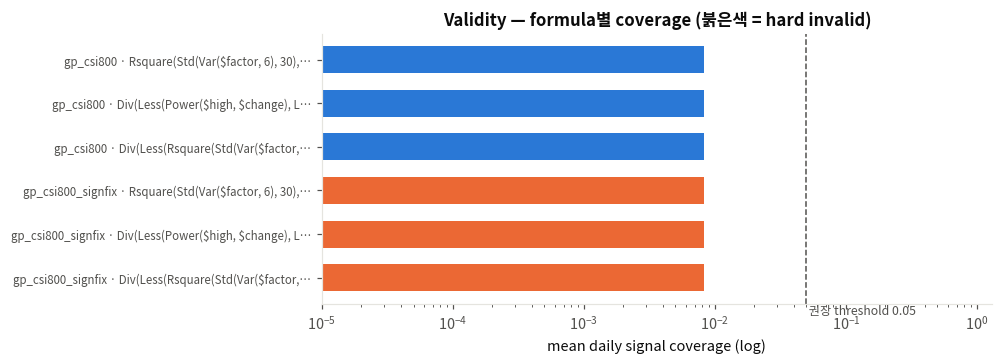

In [76]:
d = VAL.sort_values(["run", "mean_daily_coverage_ratio"]).reset_index(drop=True)
labels = d["run"] + " · " + d["formula"].map(lambda f: pshort(f, 34))
colors = [STATUS_BAD if not ok else RUN_COLOR[rn] for ok, rn in zip(d["valid"], d["run"])]
x = d["mean_daily_coverage_ratio"].clip(lower=1e-5)

fig, ax = plt.subplots(figsize=(9, max(3.2, 0.26 * len(d))), constrained_layout=True)
ax.barh(range(len(d)), x, color=colors, height=0.62)
ax.set_yticks(range(len(d)), labels, fontsize=7.5)
ax.set_xscale("log"); ax.set_xlim(1e-5, 1.3)
ax.set_xlabel("mean daily signal coverage (log)")
ax.set_title("Validity — formula별 coverage (붉은색 = hard invalid)")
ax.axvline(0.05, color=INK2, lw=1, ls="--")
ax.text(0.05, len(d) - 0.4, " 권장 threshold 0.05", color=INK2, fontsize=8, va="top")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.invert_yaxis()
plt.show()


## 3. OOS — signal-level 일반화

**train signed IC vs test IC 산점도가 아티팩트 판독의 핵심**:
- 대각선 근처 = in-sample 예측력이 유지됨
- x축 위(0 근처 수평선) = 일반화 실패
- **부호 반전 사분면(우하/좌상)** = train과 test의 방향이 반대 — 전형적 아티팩트

In [77]:
ot = []
for name, r in RUNS.items():
    o = r["oos_factor_metrics"].copy()
    o.insert(0, "run", name)
    ot.append(o)
OOS = pd.concat(ot, ignore_index=True)
ok = OOS[OOS["valid"] == True].copy()  # noqa: E712
cols = ["run", "formula", "signed_train_IC", "train_sign", "IC", "RankIC",
        "ICIR", "RankICIR", "n_ic_obs"]
t = ok[[c for c in cols if c in ok.columns]].copy()
t["formula"] = t["formula"].map(short)
t.style.format("{:+.4f}", subset=[c for c in ["signed_train_IC", "IC", "RankIC",
                                              "ICIR", "RankICIR"] if c in t.columns]) \
    .background_gradient(subset=["IC"], cmap=DIV, vmin=-0.05, vmax=0.05)


,run,formula,signed_train_IC,train_sign,IC,RankIC,ICIR,RankICIR,n_ic_obs
0,gp_csi800,"Rsquare(Std(Var($factor, 6), 30), 5)",+0.0751,1,+0.0041,+0.0127,+0.0079,+0.0242,520
1,gp_csi800,"Div(Less(Power($high, $change), Less(Rsqu…",+0.1008,1,+0.0231,+0.0165,+0.0430,+0.0312,520
2,gp_csi800,"Div(Less(Rsquare(Std(Var($factor, 6), 30)…",+0.1008,1,+0.0231,+0.0165,+0.0430,+0.0312,520
3,gp_csi800_signfix,"Rsquare(Std(Var($factor, 6), 30), 5)",+0.0748,1,+0.0041,+0.0127,+0.0079,+0.0242,520
4,gp_csi800_signfix,"Div(Less(Power($high, $change), Less(Rsqu…",+0.0746,1,+0.0231,+0.0165,+0.0430,+0.0312,520
5,gp_csi800_signfix,"Div(Less(Rsquare(Std(Var($factor, 6), 30)…",+0.0746,1,+0.0231,+0.0165,+0.0430,+0.0312,520


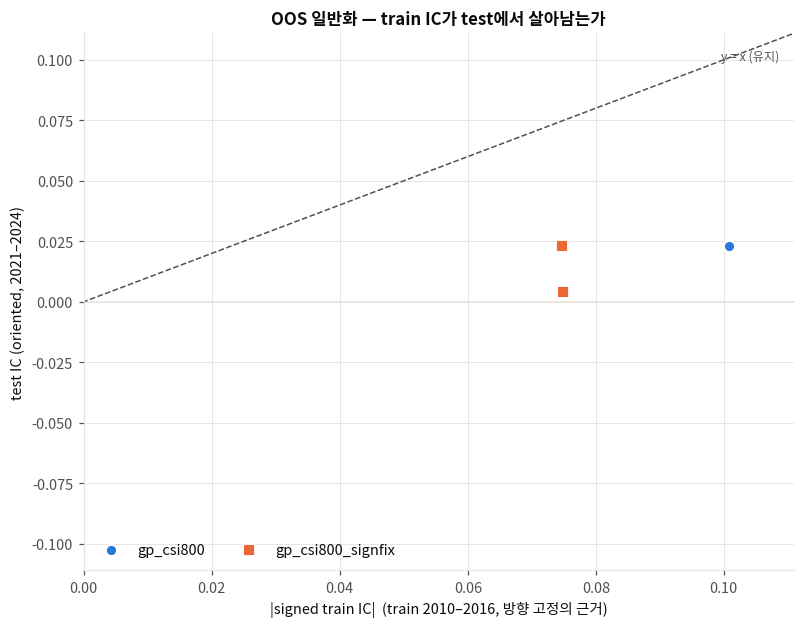

In [78]:
fig, ax = plt.subplots(figsize=(7.2, 5.6), constrained_layout=True)
lim = max(0.05, ok["signed_train_IC"].abs().max() * 1.1,
          ok["IC"].abs().max() * 1.1)
ax.axhline(0, color=GRID, lw=1); ax.axvline(0, color=GRID, lw=1)
ax.plot([-lim, lim], [-lim, lim], ls="--", lw=1, color=INK2)
ax.text(lim * 0.98, lim * 0.90, "y = x (유지)", color=INK2, fontsize=8, ha="right")
for name in RUNS:
    g = ok[ok["run"] == name]
    if g.empty:
        continue
    # oriented test IC = train_sign 적용 후 → train축도 |signed| 방향 정렬해 비교
    ax.scatter(g["signed_train_IC"].abs(), g["IC"],
               s=52, color=RUN_COLOR[name], marker=RUN_MARKER[name],
               edgecolor="white", linewidth=1.2, label=name, zorder=3)
ax.set_xlabel("|signed train IC|  (train 2010–2016, 방향 고정의 근거)")
ax.set_ylabel("test IC (oriented, 2021–2024)")
ax.set_title("OOS 일반화 — train IC가 test에서 살아남는가")
ax.legend(loc="lower left", ncols=2)
ax.set_xlim(0, lim); ax.set_ylim(-lim, lim)
plt.show()


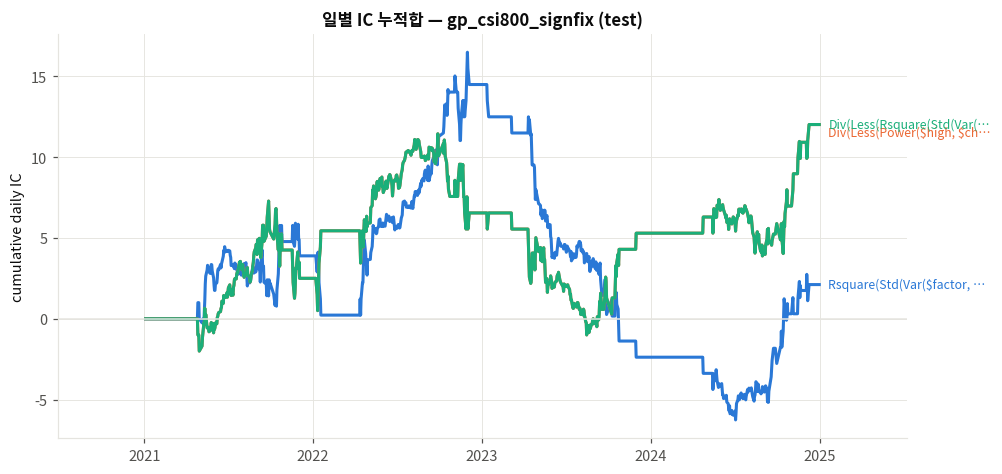

In [79]:
# 일별 IC 누적합 — SELECTED_RUN의 valid factor (horizon=1d)
r = RUNS[SELECTED_RUN]
dd = r["oos_daily"]
fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
if not dd.empty:
    dd = dd[dd["horizon"] == dd["horizon"].min()]
    valid_f = set(r["oos_factor_metrics"].query("valid == True")["formula"])
    plotted = [f for f in dd["formula_id"].unique() if f in valid_f][:6]
    ends = []
    for i, f in enumerate(plotted):
        g = dd[dd["formula_id"] == f].sort_values("date")
        cum = g["IC"].fillna(0).cumsum()
        ax.plot(pd.to_datetime(g["date"]), cum, lw=2, color=CAT[i % len(CAT)])
        ends.append((pd.to_datetime(g["date"]).iloc[-1], cum.iloc[-1], f, CAT[i % len(CAT)]))
    if ends:
        span = (max(e[1] for e in ends) - min(e[1] for e in ends)) or 1.0
        lys = spread_ys([e[1] for e in ends], 0.05 * span)
        for (ex, ey, f, c), ly in zip(ends, lys):
            ax.annotate(pshort(f, 26), (ex, ly), xytext=(6, 0),
                        textcoords="offset points", color=c, fontsize=8,
                        va="center", annotation_clip=False)
    ax.axhline(0, color=GRID, lw=1)
    ax.set_title(f"일별 IC 누적합 — {SELECTED_RUN} (test)")
    ax.set_ylabel("cumulative daily IC")
    ax.margins(x=0.13)
else:
    ax.text(0.5, 0.5, "oos_daily 없음", ha="center", va="center")
plt.show()


## 4. QD — behavioral descriptors

- PCA 지도: 각 점 = alpha 하나 (같은 run = 같은 색·마커, 크기 ∝ signal coverage)
- descriptor 히트맵: 열별 z-score 색 + **원값 직접 표기**

In [80]:
qt = []
for name, r in RUNS.items():
    q = r["qd_factor_descriptors"].copy()
    if q.empty:
        continue
    q.insert(0, "run", name)
    qt.append(q)
QD = pd.concat(qt, ignore_index=True) if qt else pd.DataFrame()
CORE = ["horizon", "volatility_response", "market_direction_response",
        "liquidity_response", "activation_breadth", "rre_qd"]
STRUCT = ["signal_coverage", "signal_weight_turnover", "liquidity_footprint"]
tcols = ["run", "formula"] + CORE + STRUCT
t = QD[[c for c in tcols if c in QD.columns]].copy()
t["formula"] = t["formula"].map(short)
t.style.format("{:+.3f}", subset=[c for c in CORE + STRUCT if c in t.columns])


,run,formula,horizon,volatility_response,market_direction_response,liquidity_response,activation_breadth,rre_qd,signal_coverage,signal_weight_turnover,liquidity_footprint
0,gp_csi800,"Rsquare(Std(Var($factor, 6), 30), 5)",+10.118,+0.999,-0.995,+0.998,+0.758,+0.866,+0.008,+0.324,+0.564
1,gp_csi800,"Div(Less(Power($high, $change), Less(Rsqu…",+7.585,+0.775,+0.635,+0.220,+0.632,+0.781,+0.008,+0.397,+0.527
2,gp_csi800,"Div(Less(Rsquare(Std(Var($factor, 6), 30)…",+7.585,+0.775,+0.635,+0.220,+0.632,+0.781,+0.008,+0.397,+0.527


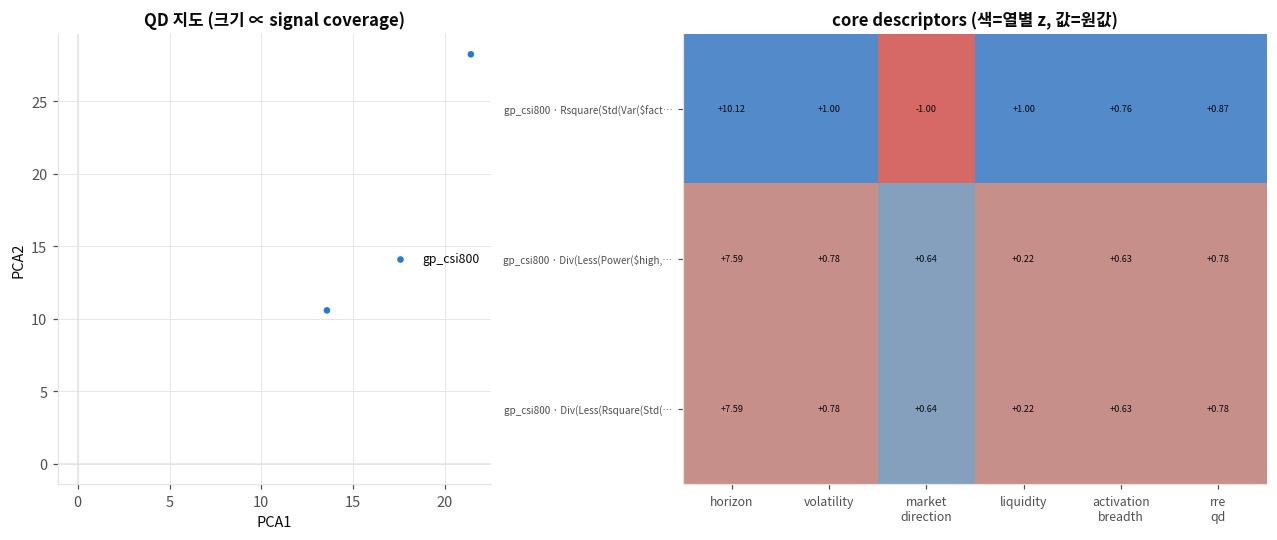

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1, 1.35]})
ax = axes[0]
for name in RUNS:
    g = QD[(QD["run"] == name)] if not QD.empty else pd.DataFrame()
    if g.empty or "PCA1" not in g.columns:
        continue
    g = g[np.isfinite(g["PCA1"].astype(float)) & np.isfinite(g["PCA2"].astype(float))]
    if g.empty:
        continue  # projection 불가(descriptor NaN) run은 legend에도 넣지 않음
    size = 30 + 90 * g["signal_coverage"].fillna(0)
    ax.scatter(g["PCA1"], g["PCA2"], s=size, color=RUN_COLOR[name],
               marker=RUN_MARKER[name], edgecolor="white", linewidth=1.2,
               label=name, zorder=3)
ax.axhline(0, color=GRID, lw=1); ax.axvline(0, color=GRID, lw=1)
ax.set_xlabel("PCA1"); ax.set_ylabel("PCA2")
ax.set_title("QD 지도 (크기 ∝ signal coverage)")
ax.legend(loc="best", fontsize=8)

ax = axes[1]
if not QD.empty:
    H = QD[["run", "formula"] + [c for c in CORE if c in QD.columns]].copy()
    H["label"] = H["run"] + " · " + H["formula"].map(lambda f: pshort(f, 22))
    M = H.set_index("label")[[c for c in CORE if c in H.columns]]
    Z = (M - M.mean()) / M.std(ddof=0).replace(0, 1)
    im = ax.imshow(Z.to_numpy(dtype=float), cmap=DIV, vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(M.shape[1]),
                  [c.replace("_response", "").replace("_", "\n") for c in M.columns],
                  fontsize=8)
    ax.set_yticks(range(len(M)), M.index, fontsize=6.5)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.iloc[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                        fontsize=6, color=INK)
    ax.set_title("core descriptors (색=열별 z, 값=원값)")
    ax.grid(False)
plt.show()


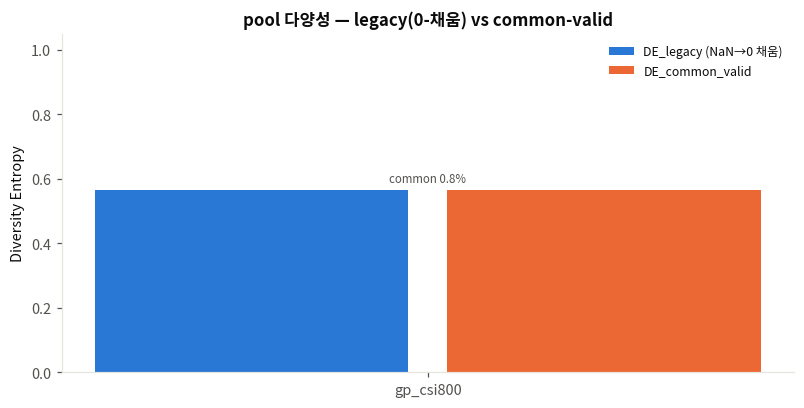

,DE_legacy,DE_common_valid,common_cell_ratio,coverage,n_gated
run,,,,,
gp_csi800,0.565976,0.565976,0.008233,0.0,3


In [82]:
# pool-level: DE_legacy vs DE_common_valid (0-채움 왜곡 관찰)
rows = []
for name, r in RUNS.items():
    p = r["qd_pool_metrics"]
    if p.empty:
        continue
    row = p.iloc[0]
    rows.append({"run": name,
                 "DE_legacy": row.get("AlphaEval_DE_legacy", np.nan),
                 "DE_common_valid": row.get("de_common_valid", np.nan),
                 "common_cell_ratio": row.get("common_cell_ratio", np.nan),
                 "coverage": row.get("coverage", np.nan),
                 "n_gated": row.get("n_gated_factors", np.nan)})
DEP = pd.DataFrame(rows).set_index("run")
fig, ax = plt.subplots(figsize=(7.2, 3.6), constrained_layout=True)
xs = np.arange(len(DEP))
w = 0.36
ax.bar(xs - w / 2, DEP["DE_legacy"], width=w - 0.04, color=CAT[0], label="DE_legacy (NaN→0 채움)")
ax.bar(xs + w / 2, DEP["DE_common_valid"], width=w - 0.04, color=CAT[1], label="DE_common_valid")
for i, run in enumerate(DEP.index):
    top = np.nanmax([DEP["DE_legacy"].iloc[i], DEP["DE_common_valid"].iloc[i], 0])
    ax.text(xs[i], top + 0.025,
            f"common {DEP['common_cell_ratio'].iloc[i]:.1%}", ha="center",
            fontsize=7.5, color=INK2)
ax.set_xticks(xs, DEP.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Diversity Entropy")
ax.set_title("pool 다양성 — legacy(0-채움) vs common-valid")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y"); ax.grid(axis="x", visible=False)
plt.show()
DEP


## 5. Backtest — 명시적 체결 가정 하의 성과

execution·비용 가정은 §1 manifest 표 참조. 곡선은 **net**(비용 차감 후) 기준.

In [83]:
bt = []
for name, r in RUNS.items():
    b = r["backtest_factor_metrics"].copy()
    b.insert(0, "run", name)
    bt.append(b)
BT = pd.concat(bt, ignore_index=True)
okb = BT[BT["valid"] == True].copy()  # noqa: E712
cols = ["run", "formula", "AnnRet_arith", "CAGR", "Sharpe", "MDD",
        "mean_daily_turnover_oneway", "total_transaction_cost"]
t = okb[[c for c in cols if c in okb.columns]].copy()
t["formula"] = t["formula"].map(short)
t.style.format("{:+.3f}", subset=[c for c in cols[2:] if c in t.columns]) \
    .background_gradient(subset=["Sharpe"], cmap=DIV, vmin=-2, vmax=2)


,run,formula,AnnRet_arith,CAGR,Sharpe,MDD,mean_daily_turnover_oneway,total_transaction_cost
0,gp_csi800,"Rsquare(Std(Var($factor, 6), 30), 5)",-0.133,-0.134,-0.926,+0.512,+0.382,+0.556
1,gp_csi800,"Div(Less(Power($high, $change), Less(Rsqu…",-0.040,-0.050,-0.262,+0.412,+0.421,+0.612
2,gp_csi800,"Div(Less(Rsquare(Std(Var($factor, 6), 30)…",-0.040,-0.050,-0.262,+0.412,+0.421,+0.612


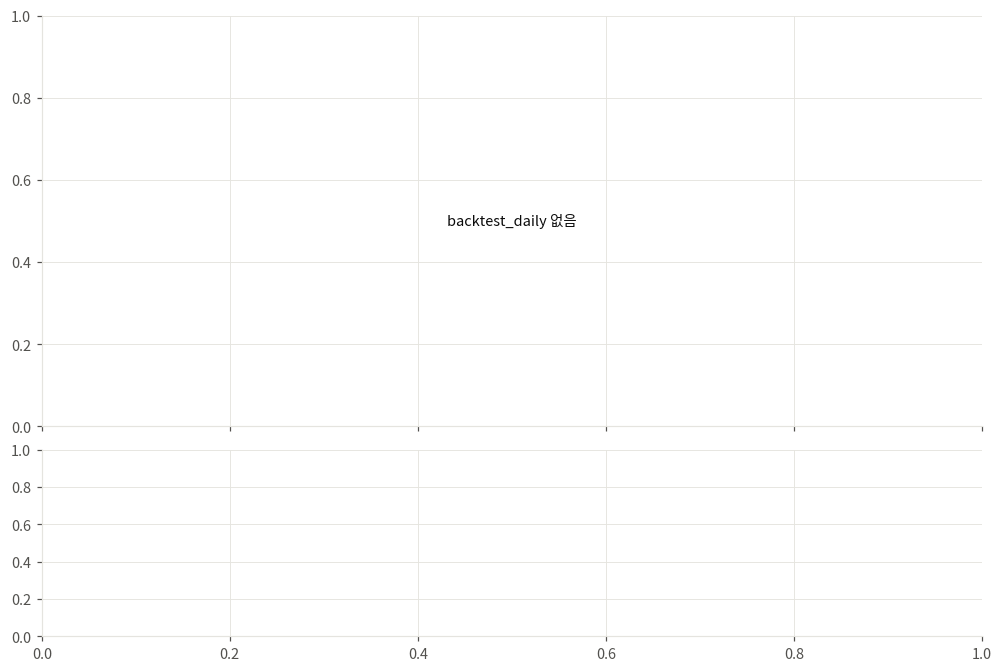

In [84]:
# 누적 수익 곡선 + drawdown — SELECTED_RUN
r = RUNS[SELECTED_RUN]
dd = r["bt_daily"]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
if not dd.empty:
    ids = list(dd["formula_id"].unique())[:6]
    best_id, best_cum = None, None
    ends = []
    for i, f in enumerate(ids):
        g = dd[dd["formula_id"] == f].sort_values("date")
        dt = pd.to_datetime(g["date"])
        cum = (1 + g["net_return"].fillna(0)).cumprod() - 1
        axes[0].plot(dt, cum, lw=2, color=CAT[i % len(CAT)])
        ends.append((dt.iloc[-1], cum.iloc[-1], f, CAT[i % len(CAT)]))
        if best_cum is None or cum.iloc[-1] > best_cum.iloc[-1]:
            best_id, best_cum, best_dt = f, cum, dt
    span = (max(e[1] for e in ends) - min(e[1] for e in ends)) or 1.0
    lys = spread_ys([e[1] for e in ends], 0.05 * span)
    for (ex, ey, f, c), ly in zip(ends, lys):
        axes[0].annotate(pshort(f, 24), (ex, ly), xytext=(6, 0),
                         textcoords="offset points", fontsize=7.5, color=c,
                         va="center", annotation_clip=False)
    axes[0].axhline(0, color=GRID, lw=1)
    axes[0].set_title(f"누적 net return — {SELECTED_RUN} "
                      f"({r['manifest'].get('execution', {}).get('execution', '?')}, 비용 차감)")
    axes[0].set_ylabel("cumulative return")
    axes[0].margins(x=0.14)
    # drawdown: 최고 성과 시리즈
    eq = 1 + best_cum
    ddown = eq / eq.cummax() - 1
    axes[1].fill_between(best_dt, ddown, 0, color=CAT[0], alpha=0.35, linewidth=0)
    axes[1].plot(best_dt, ddown, lw=1.2, color=CAT[0])
    axes[1].set_ylabel("drawdown")
    axes[1].set_title(f"drawdown — {pshort(best_id, 40)}", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "backtest_daily 없음", ha="center", va="center")
plt.show()


## 6. Cross-run 요약 — 세 평가를 한 표로

,n_formula,n_hard_valid,best factor test IC,pool IC,pool RankIC,DE_common,pool Sharpe,pool MDD
run,,,,,,,,
gp_csi800,3,3,+0.0231,+0.0003,+0.0017,+0.5660,-0.4479,+0.4451
gp_csi800_signfix,3,3,+0.0231,+0.0003,+0.0017,+nan,+nan,+nan


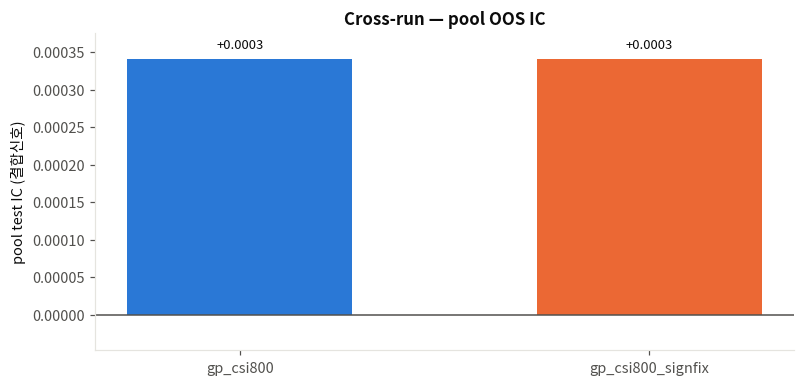

In [85]:
rows = []
for name, r in RUNS.items():
    v = r["validity_factor_metrics"]
    op = r["oos_pool_metrics"]
    qp = r["qd_pool_metrics"]
    bp = r["backtest_pool_metrics"]
    of = r["oos_factor_metrics"]
    okf = of[of.get("valid", pd.Series(dtype=bool)) == True] if not of.empty else of  # noqa: E712
    rows.append({
        "run": name,
        "n_formula": len(v),
        "n_hard_valid": int(v["hard_valid"].sum()) if "hard_valid" in v else np.nan,
        "best factor test IC": okf["IC"].max() if "IC" in okf else np.nan,
        "pool IC": op.iloc[0].get("IC", np.nan) if len(op) else np.nan,
        "pool RankIC": op.iloc[0].get("RankIC", np.nan) if len(op) else np.nan,
        "DE_common": qp.iloc[0].get("de_common_valid", np.nan) if len(qp) else np.nan,
        "pool Sharpe": bp.iloc[0].get("Sharpe", np.nan) if len(bp) else np.nan,
        "pool MDD": bp.iloc[0].get("MDD", np.nan) if len(bp) else np.nan,
    })
SUM = pd.DataFrame(rows).set_index("run")
display(SUM.style.format("{:+.4f}", subset=[c for c in SUM.columns
                                            if c not in ("n_formula", "n_hard_valid")])
        .format("{:.0f}", subset=["n_formula", "n_hard_valid"]))

fig, ax = plt.subplots(figsize=(7.2, 3.4), constrained_layout=True)
xs = np.arange(len(SUM))
vals = SUM["pool IC"].astype(float)
ax.bar(xs, vals, width=0.55, color=[RUN_COLOR[r_] for r_ in SUM.index])
lo = min(float(np.nanmin(vals)), 0.0); hi = max(float(np.nanmax(vals)), 0.0)
span = (hi - lo) or 1.0
ax.set_ylim(lo - 0.14 * span, hi + 0.10 * span)
for i, v in enumerate(vals):
    if np.isfinite(v):
        off = 0.03 * span
        ax.text(xs[i], v + (off if v >= 0 else -off), f"{v:+.4f}",
                ha="center", va="bottom" if v >= 0 else "top",
                fontsize=8.5, color=INK)
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(xs, SUM.index)
ax.set_ylabel("pool test IC (결합신호)")
ax.set_title("Cross-run — pool OOS IC")
ax.grid(axis="y"); ax.grid(axis="x", visible=False)
plt.show()


---
### 해석 시 주의

- **Validity coverage가 낮은 factor의 IC/backtest는 신뢰하지 말 것** — 초미니
  cross-section의 산물일 수 있다 (§2의 threshold 참고선).
- QD `coverage`는 final pool(점 ≤10개)에서는 노이즈 — DE·NN 중심으로 볼 것.
- pool 지표는 weights가 `equal_default`면 참고용.
- 이 노트북은 관찰 전용 — 지표 정의는 `docs/METRICS.md`,
  스키마는 `docs/DATA_CONTRACT.md`.
